# 📧 Email Spam Detection with Machine Learning

**Submitted By:** Tarannum Mohammad Nadaf  
**Organization:** Oasis Infobyte  
**Track:** Data Science  
**Project:** Email Spam Detection with Machine Learning

## Import Libraries

Import all the required Python libraries.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from wordcloud import WordCloud

## Load Dataset

Load the spam email dataset.

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Exploratory Data Analysis (EDA)

Check the dataset information and statistics.

In [3]:
print("Shape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

Shape
(5572, 5)

Columns
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

Data Types
v1            object
v2            object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
dtype: object

Missing Values
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


## Data Cleaning

Remove unnecessary columns and rename the remaining columns.

In [4]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

df = df.rename(columns={
    "v1": "label",
    "v2": "message"
})

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Class Distribution

Check the number of spam and ham messages.

In [5]:
print(df["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


## Class Distribution Chart

Visualize the distribution of spam and ham messages.

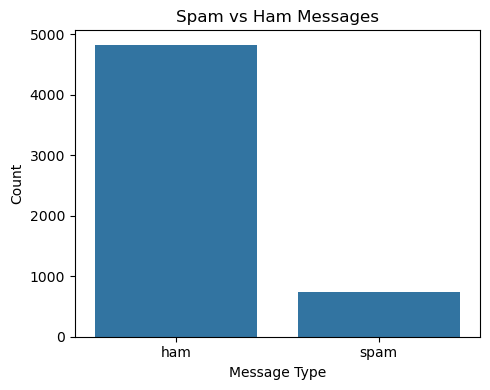

In [6]:
plt.figure(figsize=(5,4))

sns.countplot(x="label", data=df)

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## Text Preprocessing

Convert text to lowercase, remove punctuation, and remove stopwords.

In [7]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()

    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words).strip()

df["clean_message"] = df["message"].apply(clean_text)

df.head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## TF-IDF Vectorization

Convert text into numerical features using TF-IDF.

In [8]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["clean_message"])

y = df["label"]

## Train-Test Split

Split the dataset into training and testing data.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Verify Data

Check the shape of training and testing data.

In [10]:
print("X_train Shape :", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape : (4457, 9376)
X_test Shape : (1115, 9376)
y_train Shape : (4457,)
y_test Shape : (1115,)


## Multinomial Naive Bayes

Train the Multinomial Naive Bayes model.

In [11]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

## Model Evaluation

Evaluate the Multinomial Naive Bayes model.

In [12]:
acc_nb = accuracy_score(y_test, pred_nb)

print("Naive Bayes Accuracy:", acc_nb)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred_nb))

print("\nClassification Report")
print(classification_report(y_test, pred_nb))

Naive Bayes Accuracy: 0.9623318385650225

Confusion Matrix
[[966   0]
 [ 42 107]]

Classification Report
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



## Logistic Regression

Train the Logistic Regression model.

In [13]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

## Model Evaluation

Evaluate the Logistic Regression model.

In [14]:
acc_lr = accuracy_score(y_test, pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred_lr))

print("\nClassification Report")
print(classification_report(y_test, pred_lr))

Logistic Regression Accuracy: 0.9488789237668162

Confusion Matrix
[[965   1]
 [ 56  93]]

Classification Report
              precision    recall  f1-score   support

         ham       0.95      1.00      0.97       966
        spam       0.99      0.62      0.77       149

    accuracy                           0.95      1115
   macro avg       0.97      0.81      0.87      1115
weighted avg       0.95      0.95      0.94      1115



## Model Comparison

Compare the performance of both models.

In [15]:
print("Naive Bayes Accuracy :", round(acc_nb, 4))
print("Logistic Regression Accuracy :", round(acc_lr, 4))

if acc_nb > acc_lr:
    print("\nBest Model : Multinomial Naive Bayes")
elif acc_lr > acc_nb:
    print("\nBest Model : Logistic Regression")
else:
    print("\nBoth Models Perform Equally Well")

Naive Bayes Accuracy : 0.9623
Logistic Regression Accuracy : 0.9489

Best Model : Multinomial Naive Bayes


## Spam Prediction

Predict whether a new message is spam or ham.

In [16]:
message = ["Congratulations! You have won a free iPhone. Claim your prize now!"]

message_clean = [clean_text(msg) for msg in message]

message_tfidf = tfidf.transform(message_clean)

prediction = nb.predict(message_tfidf)

print("Prediction :", prediction[0])

Prediction : spam


## WordCloud

Visualize the most common words in spam messages.

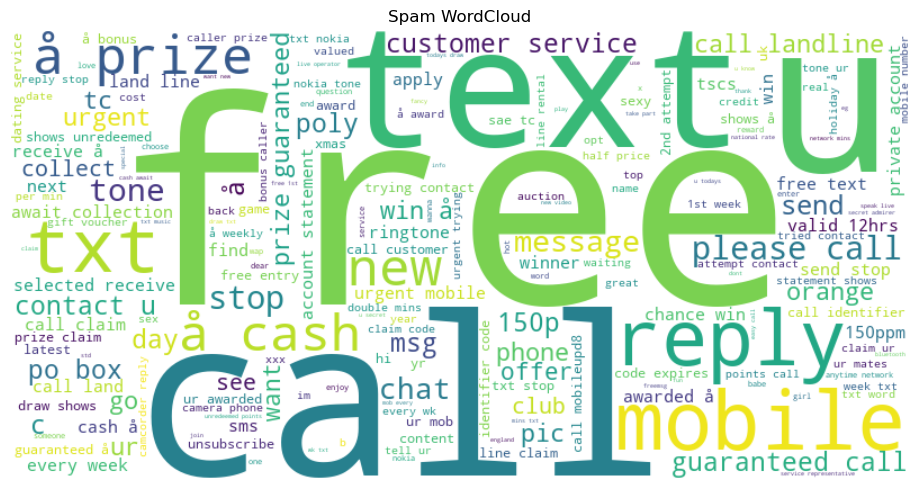

In [17]:
spam_words = " ".join(df[df["label"] == "spam"]["clean_message"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Spam WordCloud")
plt.tight_layout()
plt.show()

## WordCloud

Visualize the most common words in ham messages.

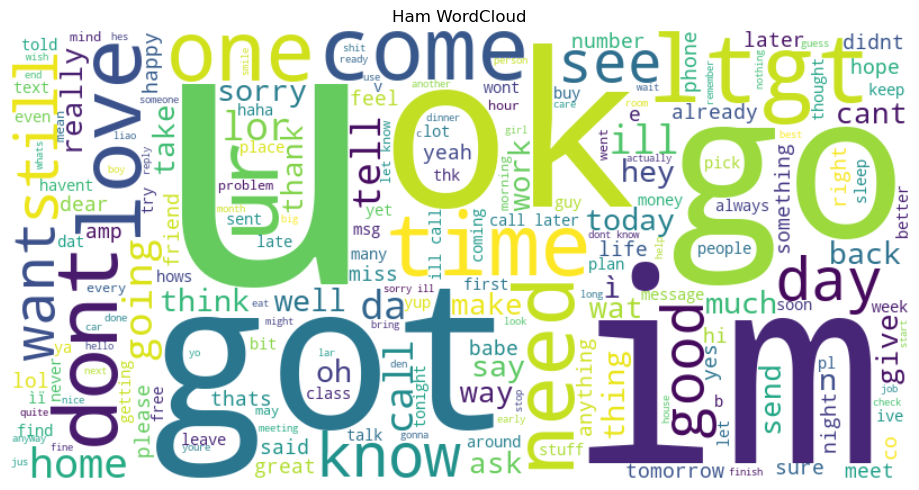

In [18]:
ham_words = " ".join(df[df["label"] == "ham"]["clean_message"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Ham WordCloud")
plt.tight_layout()
plt.show()

## Results

- Naive Bayes Accuracy: **0.9623**
- Logistic Regression Accuracy: **0.9489**
- Best Model: **Multinomial Naive Bayes**
- Prediction for the sample message: **Spam**

## Conclusion

This project successfully classified SMS messages as spam or ham using machine learning.

Two models, Multinomial Naive Bayes and Logistic Regression, were trained and evaluated. The Multinomial Naive Bayes model achieved the highest accuracy of **0.9623**, making it the best-performing model for this dataset.

The trained model can also predict whether a new message is spam or ham.